# 15. 自适应Saliency遮蔽攻击对抗性训练

## 15.0 主要内容介绍

本实验实现基于Saliency（简单梯度）的**自适应遮蔽攻击**对抗性训练：

1. **Saliency遮蔽攻击**: 使用简单梯度计算像素重要性，选择最重要的区域进行遮蔽
2. **自适应遮蔽攻击 (Adaptive)**: 
   - 渐进式增加遮蔽区域数量(n=1..N)和遮蔽半径(r=1..R)
   - 逐样本早停：攻击成功即停止，使用最小遮蔽量
   - 保留数字的语义可辨识性
3. **对抗性训练**: 使用自适应遮蔽攻击生成对抗样本进行训练

### 与固定遮蔽攻击的区别
- **固定攻击**: 直接遮蔽top_k个最重要区域，可能破坏数字语义
- **自适应攻击**: 使用最小遮蔽量达成攻击，数字语义更清晰

### 与IntegratedGradients版本的区别
- Saliency使用简单梯度 `|∂F/∂x|`，计算更快
- IntegratedGradients需要积分近似，更精确但计算慢

## 15.1 导入相关模块

In [ ]:
import sys
sys.path.insert(0, r'D:\软件\对抗性防御\对抗性防御-1\03.代码')
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import pandas as pd
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import os
import logging
import copy
from tqdm import tqdm

from occlusion_attack import SaliencyOcclusionAttack, AdaptiveSaliencyOcclusionAttack
from models import LeNet5
from utils import load_mnist_test
import test
test_fn = test.test

logger = logging.getLogger('base')
logger.setLevel(logging.DEBUG)
formatter = logging.Formatter(fmt='%(asctime)s %(message)s', datefmt='%Y%m%d %H:%M:%S')
stream_handler = logging.StreamHandler()
stream_handler.setLevel(logging.DEBUG)
stream_handler.setFormatter(formatter)
logger.addHandler(stream_handler)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 中文字体设置
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

print(f'Device: {device}')

## 15.2 Saliency遮蔽攻击演示

使用简单梯度计算每个像素对预测的重要性，然后遮蔽最重要的区域。

In [2]:
# 加载标准模型
std_state = torch.load('./save_model/50epoch/mnist_lenet5.pth', map_location=device, weights_only=False)
std_lenet = LeNet5().to(device)
std_lenet.load_state_dict(std_state['net'])
std_lenet.eval()
print('标准LeNet5模型加载完成')

# 加载测试集
imgs, lbls = load_mnist_test()
print(f'测试集大小: {imgs.shape[0]}')

标准LeNet5模型加载完成
测试集大小: 10000


In [3]:
# 测试干净样本准确率
clean_acc, _ = test_fn(std_lenet, imgs, lbls, bs=250, mode='clean')
logger.info(f'标准模型 - 干净样本准确率: {clean_acc:.2f}%')

20260404 17:14:36 标准模型 - 干净样本准确率: 99.00%


### 15.2.1 固定遮蔽攻击测试

In [4]:
# 测试不同top_k参数
top_k_values = [3, 5, 9, 15]
fixed_results = {}

for top_k in top_k_values:
    attack = SaliencyOcclusionAttack(std_lenet, top_k=top_k, kernel_size=3, occlu_color=0.0)
    acc, preds = test_fn(nn.Sequential(attack, std_lenet), imgs, lbls, bs=250, mode='attack')
    fixed_results[top_k] = {'acc': acc, 'preds': preds}
    logger.info(f'Fixed遮蔽攻击 (top_k={top_k}): 准确率={acc:.2f}%')

20260404 17:14:45 Fixed遮蔽攻击 (top_k=3): 准确率=86.82%
20260404 17:15:02 Fixed遮蔽攻击 (top_k=5): 准确率=80.99%
20260404 17:15:37 Fixed遮蔽攻击 (top_k=9): 准确率=71.19%
20260404 17:16:36 Fixed遮蔽攻击 (top_k=15): 准确率=59.78%


### 15.2.2 自适应遮蔽攻击测试

In [5]:
# 测试不同N参数
N_values = [3, 5, 7, 10]
adaptive_results = {}

for N in N_values:
    attack = AdaptiveSaliencyOcclusionAttack(std_lenet, N=N, R=3, c=0.0)
    acc, preds = test_fn(nn.Sequential(attack, std_lenet), imgs, lbls, bs=250, mode='attack')
    adaptive_results[N] = {'acc': acc, 'preds': preds}
    logger.info(f'Adaptive遮蔽攻击 (N={N}, R=3): 准确率={acc:.2f}%')

20260404 17:16:47 Adaptive遮蔽攻击 (N=3, R=3): 准确率=49.45%
20260404 17:17:03 Adaptive遮蔽攻击 (N=5, R=3): 准确率=34.33%
20260404 17:17:25 Adaptive遮蔽攻击 (N=7, R=3): 准确率=25.09%
20260404 17:17:54 Adaptive遮蔽攻击 (N=10, R=3): 准确率=15.95%


### 15.2.3 可视化攻击效果（含真实值和预测）

In [6]:
def imshow_with_pred(img, model, true_label, ax=None, title_prefix=''):
    """显示图像并标注真实标签和预测结果"""
    npimg = img.cpu().squeeze().numpy()
    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device)).argmax(dim=1).item()
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(3, 3))
    
    ax.imshow(npimg, cmap='gray')
    correct_str = 'OK' if pred == true_label else 'X'
    ax.set_title(f'{title_prefix}\n真实:{true_label} 预测:{pred} {correct_str}', fontsize=10)
    ax.axis('off')
    return pred == true_label

# 选择展示的样本（每个数字一个）
sample_indices = []
shown = set()
for i in range(len(lbls)):
    label = int(lbls[i].item())
    if label not in shown:
        shown.add(label)
        sample_indices.append(i)
    if len(shown) == 10:
        break

print(f'展示样本索引: {sample_indices}')

展示样本索引: [0, 1, 2, 3, 5, 13, 14, 15, 23, 33]


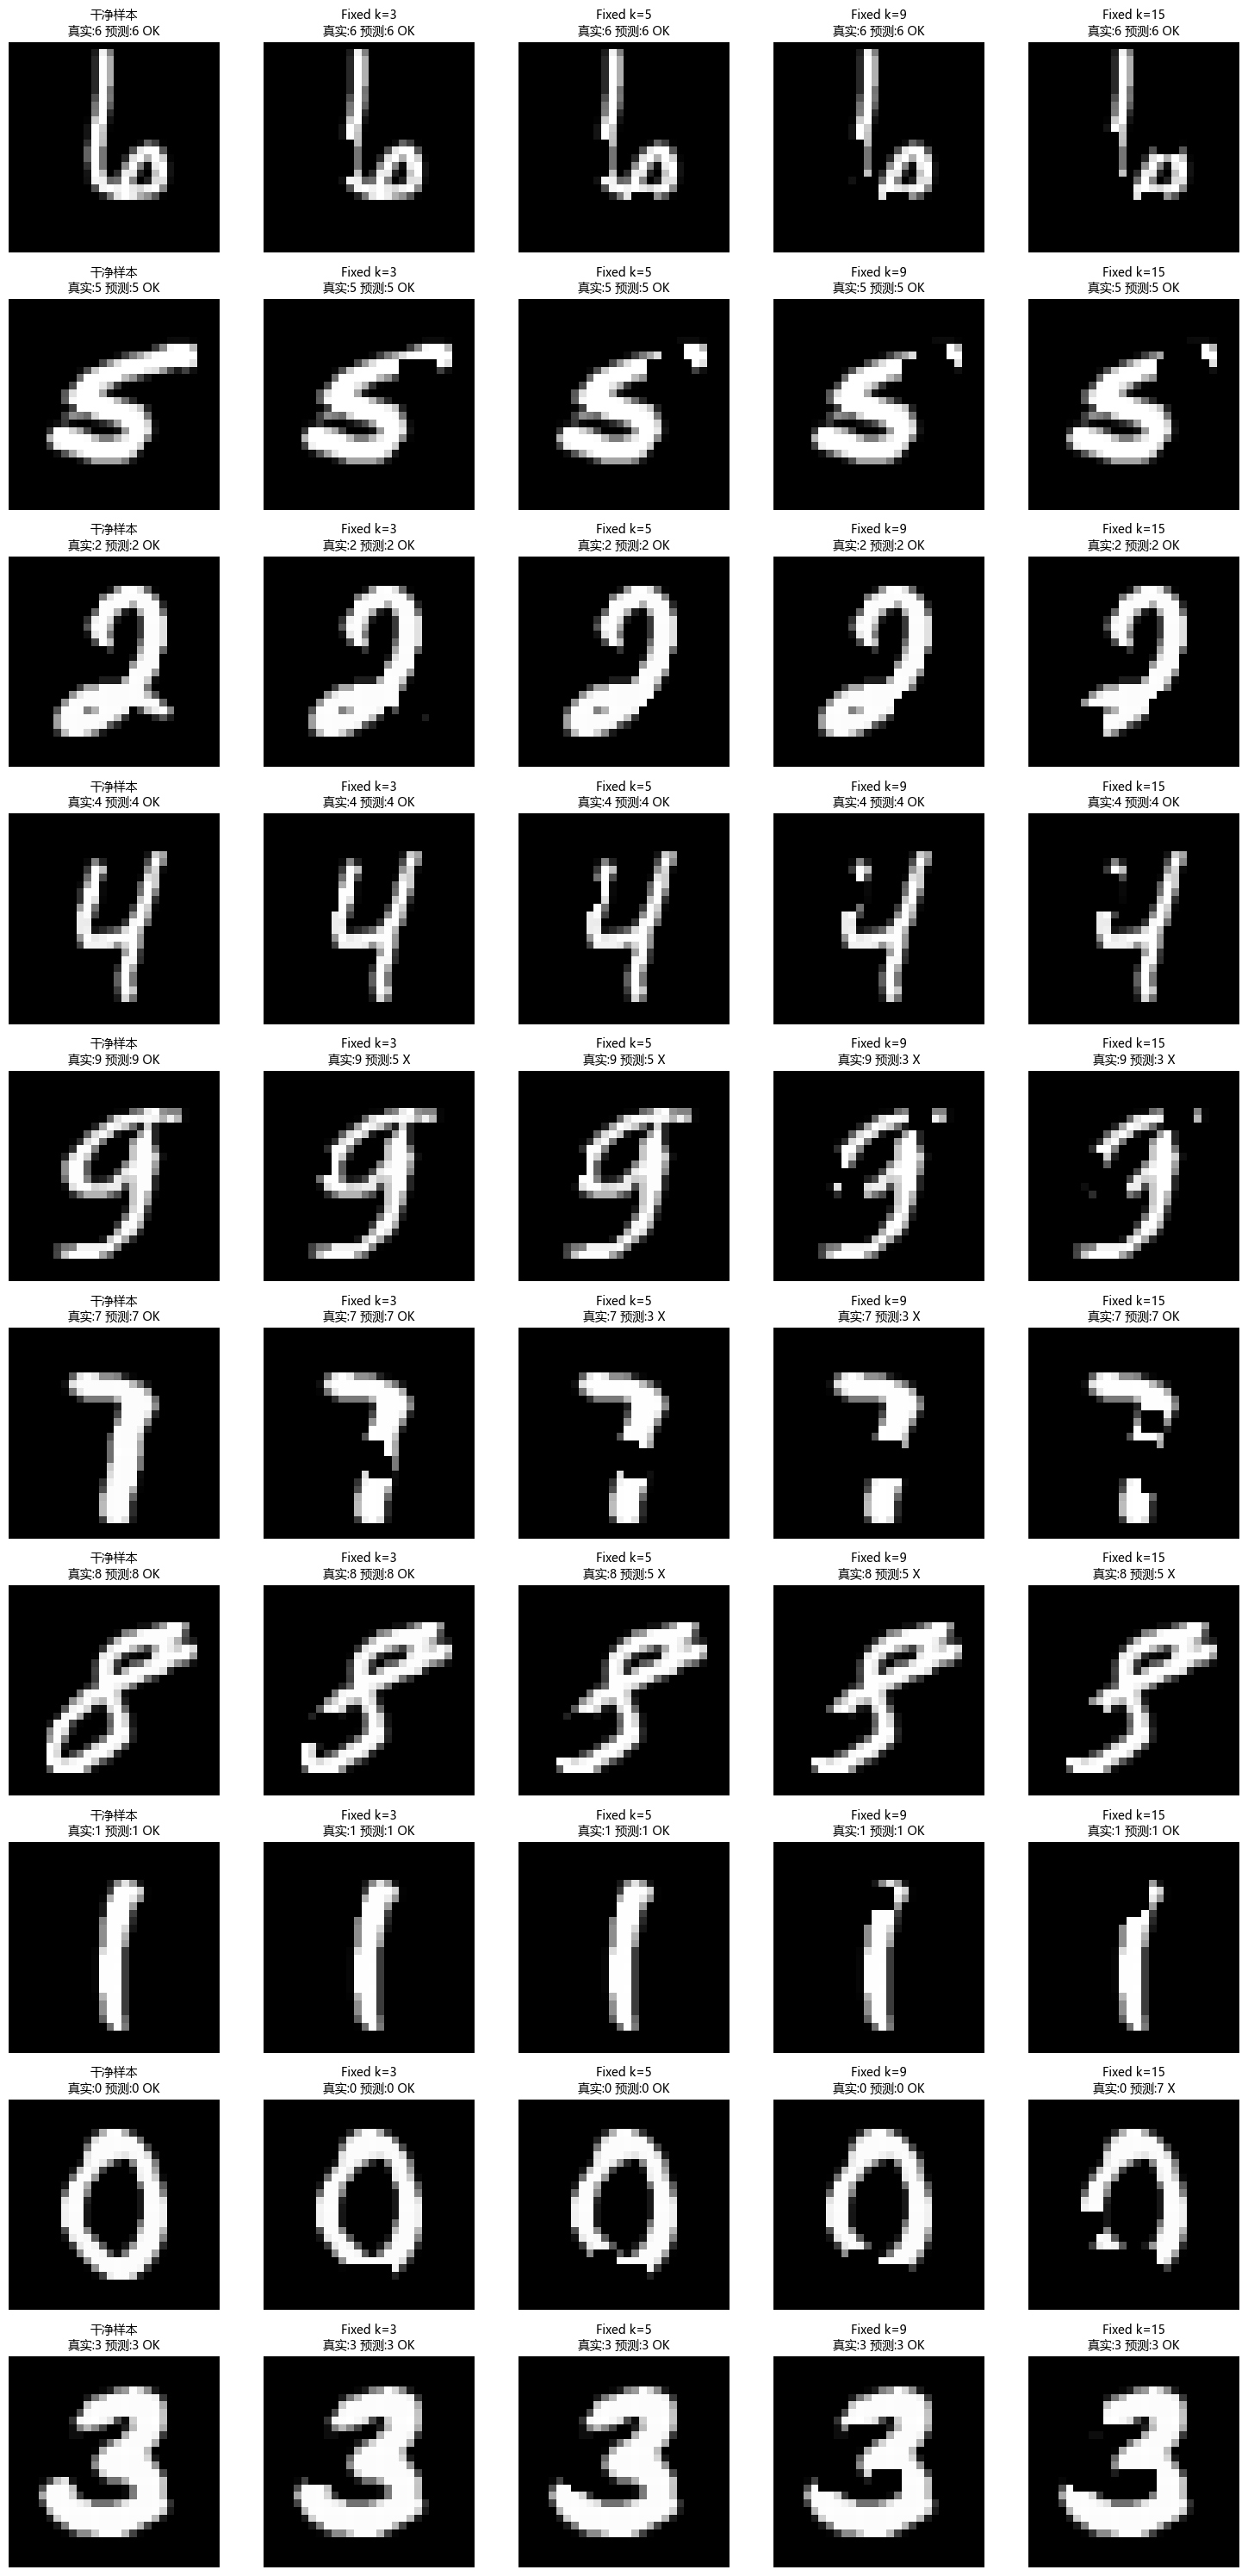

固定遮蔽攻击可视化已保存


In [7]:
# 可视化固定遮蔽攻击效果
fig, axes = plt.subplots(10, 5, figsize=(15, 30))

for row, idx in enumerate(sample_indices):
    x = imgs[idx:idx+1].to(device)
    y = lbls[idx:idx+1].to(device)
    true_label = int(y.item())
    
    # 干净样本
    imshow_with_pred(x.squeeze(0), std_lenet, true_label, ax=axes[row, 0], title_prefix='干净样本')
    
    # 不同top_k的遮蔽攻击
    for col, top_k in enumerate(top_k_values):
        attack = SaliencyOcclusionAttack(std_lenet, top_k=top_k, kernel_size=3, occlu_color=0.0)
        x_adv = attack((x, y))
        imshow_with_pred(x_adv.squeeze(0), std_lenet, true_label, 
                        ax=axes[row, col+1], title_prefix=f'Fixed k={top_k}')

plt.tight_layout()
plt.savefig('./results_figures/saliency_fixed_attack_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('固定遮蔽攻击可视化已保存')

In [ ]:
# 可视化固定遮蔽攻击效果
fig, axes = plt.subplots(10, 5, figsize=(15, 30))

for row, idx in enumerate(sample_indices):
    x = imgs[idx:idx+1].to(device)
    y = lbls[idx:idx+1].to(device)
    true_label = int(y.item())
    
    # 干净样本
    imshow_with_pred(x.squeeze(0), std_lenet, true_label, ax=axes[row, 0], title_prefix='干净样本')
    
    # 不同top_k的遮蔽攻击
    for col, top_k in enumerate(top_k_values):
        attack = AdaptiveSaliencyOcclusionAttack(std_lenet, top_k=top_k, kernel_size=3, occlu_color=0.0)
        x_adv = attack((x, y))
        imshow_with_pred(x_adv.squeeze(0), std_lenet, true_label, 
                        ax=axes[row, col+1], title_prefix=f'Adaptive k={top_k}')

plt.tight_layout()
plt.savefig('./results_figures/saliency_Adaptive_attack_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('自适应遮蔽攻击可视化已保存')

## 15.3 基于自适应Saliency遮蔽攻击的对抗性训练

与固定遮蔽攻击对抗性训练不同，自适应遮蔽攻击：
1. 渐进式增加遮蔽区域数量和半径
2. 逐样本早停：一旦攻击成功（预测改变）即停止该样本的遮蔽
3. 使用最小遮蔽量，保留数字的语义可辨识性

In [8]:
# 超参数
EPOCH = 50
BATCH_SIZE = 256
LR = 0.001

# 自适应遮蔽攻击参数
N = 5              # 最大遮蔽区域数量
R = 3              # 最大遮蔽半径
C_COLOR = 0.0      # 黑色遮蔽

print(f'训练参数: EPOCH={EPOCH}, BATCH_SIZE={BATCH_SIZE}, LR={LR}')
print(f'自适应遮蔽参数: N={N}, R={R}, C_COLOR={C_COLOR}')

# 加载数据集
train_dataset = torchvision.datasets.MNIST(
    root="./data/", train=True, download=False, transform=transforms.ToTensor())
test_dataset = torchvision.datasets.MNIST(
    root="./data/", train=False, download=False, transform=transforms.ToTensor())
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

print(f'训练集: {len(train_dataset)}, 测试集: {len(test_dataset)}')

训练参数: EPOCH=50, BATCH_SIZE=256, LR=0.001
自适应遮蔽参数: N=5, R=3, C_COLOR=0.0
训练集: 60000, 测试集: 10000


In [9]:
# 定义自适应Saliency遮蔽攻击对抗性训练模块
class AdaptiveSaliencyOcclusionAT(nn.Module):
    """基于自适应Saliency遮蔽攻击的对抗性训练
    
    与固定遮蔽攻击的区别：
    - 渐进式增加遮蔽区域数量(n=1..N)和遮蔽半径(r=1..R)
    - 逐样本早停：攻击成功即停止，使用最小遮蔽量
    """
    
    def __init__(self, model, N=5, R=3, c=0.0):
        super().__init__()
        self.model = model
        self.attack = AdaptiveSaliencyOcclusionAttack(model, N=N, R=R, c=c)
    
    def forward(self, x, y=None):
        if y is None:
            return self.model(x)
        
        # 生成对抗样本
        training = self.model.training
        self.model.eval()
        x_adv = self.attack((x, y))
        if training:
            self.model.train()
        
        return self.model(x_adv)

# 初始化模型
cnn = LeNet5().to(device)
cnn_at = AdaptiveSaliencyOcclusionAT(cnn, N=N, R=R, c=C_COLOR)

optimizer = torch.optim.Adam(cnn.parameters(), lr=LR)
loss_fn = nn.CrossEntropyLoss()

num_params = sum(p.numel() for p in cnn.parameters() if p.requires_grad)
print(f'模型参数量: {num_params}')
print(f'使用自适应遮蔽攻击: N={N}, R={R}')

模型参数量: 61706
使用自适应遮蔽攻击: N=5, R=3


In [10]:
# 训练循环
train_accs, train_losses = [], []
test_accs, test_losses = [], []
test_clean_accs = []
best_acc = 0
best_state = None

for epoch in range(EPOCH):
    # 训练
    cnn_at.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for inputs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCH}'):
        n = labels.size(0)
        inputs, labels = inputs.to(device), labels.to(device)
        
        outputs = cnn_at(inputs, labels)
        loss = loss_fn(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        pred = outputs.argmax(dim=1)
        train_correct += (pred == labels).sum().item()
        train_total += n
        train_loss += loss.item() * n
    
    train_acc = train_correct / train_total
    train_loss_avg = train_loss / train_total
    train_accs.append(train_acc)
    train_losses.append(train_loss_avg)
    
    # 测试（对抗样本）
    cnn_at.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0
    test_clean_correct = 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            n = labels.size(0)
            inputs, labels = inputs.to(device), labels.to(device)
            
            # 干净样本测试
            pred_clean = cnn(inputs).argmax(dim=1)
            test_clean_correct += (pred_clean == labels).sum().item()
            
            # 对抗样本测试
            outputs = cnn_at(inputs, labels)
            loss = loss_fn(outputs, labels)
            pred = outputs.argmax(dim=1)
            test_correct += (pred == labels).sum().item()
            test_total += n
            test_loss += loss.item() * n
    
    test_acc = test_correct / test_total
    test_loss_avg = test_loss / test_total
    test_clean_acc = test_clean_correct / test_total
    
    test_accs.append(test_acc)
    test_losses.append(test_loss_avg)
    test_clean_accs.append(test_clean_acc)
    
    logger.info(f'Epoch {epoch+1}: Train Loss={train_loss_avg:.4f}, Train Acc={100*train_acc:.2f}%, '
                f'Test(Robust)={100*test_acc:.2f}%, Test(Clean)={100*test_clean_acc:.2f}%')
    
    # 保存最佳模型
    if test_acc > best_acc:
        best_acc = test_acc
        best_state = copy.deepcopy(cnn.state_dict())

# 加载最佳模型
if best_state is not None:
    cnn.load_state_dict(best_state)
    print(f'加载最佳模型，鲁棒准确率: {100*best_acc:.2f}%')

20260404 17:20:06 Epoch 1: Train Loss=0.5890, Train Acc=75.47%, Test(Robust)=89.37%, Test(Clean)=94.29%
20260404 17:22:25 Epoch 2: Train Loss=0.2126, Train Acc=89.96%, Test(Robust)=91.49%, Test(Clean)=96.13%
20260404 17:24:50 Epoch 3: Train Loss=0.1697, Train Acc=91.70%, Test(Robust)=92.15%, Test(Clean)=97.36%
20260404 17:27:17 Epoch 4: Train Loss=0.1550, Train Acc=92.28%, Test(Robust)=92.52%, Test(Clean)=97.60%
20260404 17:29:33 Epoch 5: Train Loss=0.1480, Train Acc=92.64%, Test(Robust)=92.35%, Test(Clean)=97.64%
20260404 17:31:48 Epoch 6: Train Loss=0.1394, Train Acc=92.98%, Test(Robust)=93.08%, Test(Clean)=97.42%
20260404 17:34:08 Epoch 7: Train Loss=0.1387, Train Acc=92.86%, Test(Robust)=92.29%, Test(Clean)=98.05%
20260404 17:36:24 Epoch 8: Train Loss=0.1342, Train Acc=92.99%, Test(Robust)=91.53%, Test(Clean)=97.83%
20260404 17:38:25 Epoch 9: Train Loss=0.1299, Train Acc=93.16%, Test(Robust)=93.69%, Test(Clean)=98.62%
20260404 17:40:35 Epoch 10: Train Loss=0.1202, Train Acc=93.77%,

加载最佳模型，鲁棒准确率: 94.30%


In [11]:
# 保存模型
state = {
    'net': cnn.state_dict(),
    'epoch': EPOCH,
    'train_losses': train_losses,
    'train_accs': train_accs,
    'test_losses': test_losses,
    'test_accs': test_accs,
    'test_clean_accs': test_clean_accs,
    'params': {'N': N, 'R': R, 'c': C_COLOR}
}

save_dir = f'./save_model/{EPOCH}epoch'
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, f'mnist_lenet5_AdaptiveSaliencyOcclusionAT_{N}_{R}.pth')
torch.save(state, save_path)
print(f'模型已保存: {save_path}')

模型已保存: ./save_model/50epoch\mnist_lenet5_AdaptiveSaliencyOcclusionAT_5_3.pth


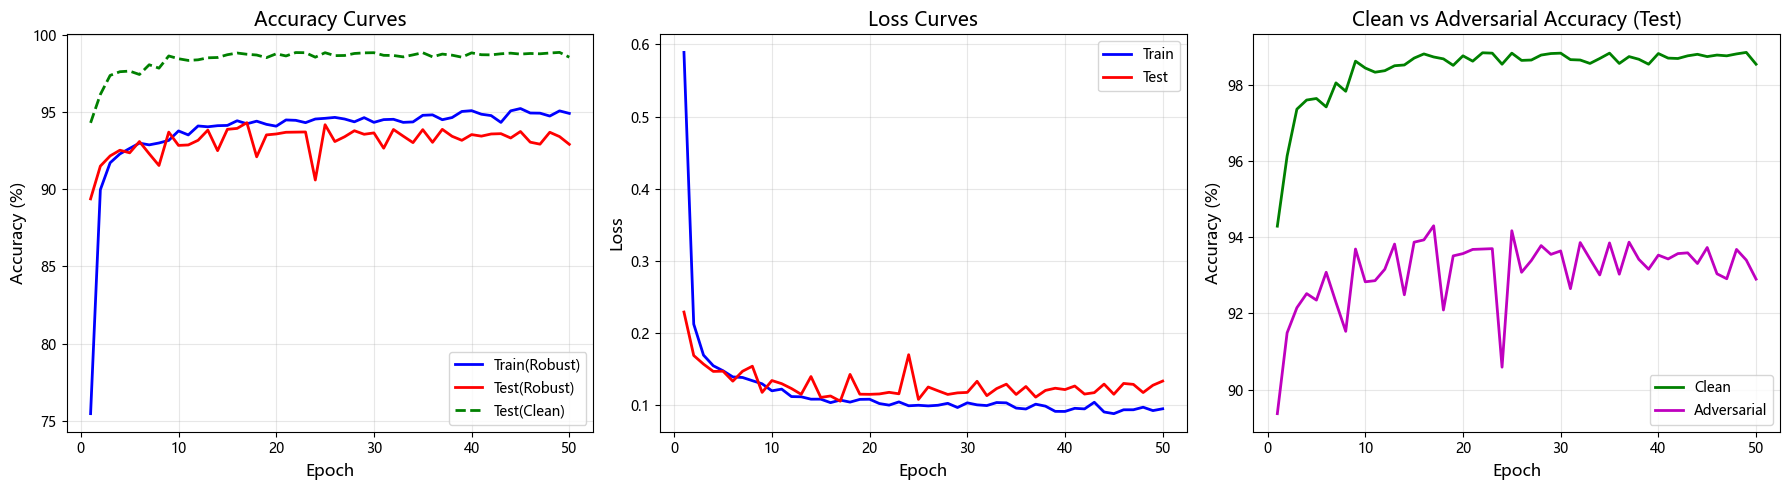

训练完成: 最终测试准确率 - 干净=98.54%, 对抗=92.90%


In [12]:
# 绘制训练曲线
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs = list(range(1, EPOCH+1))

# 准确率曲线
axes[0].plot(epochs, [100*a for a in train_accs], 'b-', label='Train(Robust)', linewidth=2)
axes[0].plot(epochs, [100*a for a in test_accs], 'r-', label='Test(Robust)', linewidth=2)
axes[0].plot(epochs, [100*a for a in test_clean_accs], 'g--', label='Test(Clean)', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_title('Accuracy Curves', fontsize=14)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# 损失曲线
axes[1].plot(epochs, train_losses, 'b-', label='Train', linewidth=2)
axes[1].plot(epochs, test_losses, 'r-', label='Test', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Loss Curves', fontsize=14)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# 干净 vs 对抗准确率
axes[2].plot(epochs, [100*a for a in test_clean_accs], 'g-', label='Clean', linewidth=2)
axes[2].plot(epochs, [100*a for a in test_accs], 'm-', label='Adversarial', linewidth=2)
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('Accuracy (%)', fontsize=12)
axes[2].set_title('Clean vs Adversarial Accuracy (Test)', fontsize=14)
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./results_figures/saliency_at_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'训练完成: 最终测试准确率 - 干净={100*test_clean_accs[-1]:.2f}%, 对抗={100*test_accs[-1]:.2f}%')

## 15.4 鲁棒性评测

对训练好的模型进行多角度评测，包括：
1. 不同参数的固定遮蔽攻击
2. 不同参数的自适应遮蔽攻击

In [13]:
# 加载测试集
imgs, lbls = load_mnist_test()

# 干净样本准确率
cnn.eval()
clean_acc, clean_preds = test_fn(cnn, imgs, lbls, bs=250, mode='clean')
logger.info(f'Saliency-AT模型 - 干净样本准确率: {clean_acc:.2f}%')

20260404 20:16:47 Saliency-AT模型 - 干净样本准确率: 98.73%


### 15.4.1 自适应遮蔽攻击评测（不同N和R）

In [14]:
# 测试不同N和R参数组合
N_test = [3, 5, 7, 10]
R_test = [2, 3, 4]
adaptive_eval_results = []

# 测试不同N（固定R=3）
for N_val in N_test:
    attack = AdaptiveSaliencyOcclusionAttack(cnn, N=N_val, R=3, c=0.0)
    acc, preds = test_fn(nn.Sequential(attack, cnn), imgs, lbls, bs=250, mode='attack')
    adaptive_eval_results.append({
        'attack': 'Adaptive',
        'param': f'N={N_val},R=3',
        'N': N_val,
        'R': 3,
        'accuracy': acc
    })
    logger.info(f'Adaptive遮蔽攻击 (N={N_val}, R=3): {acc:.2f}%')

# 测试不同R（固定N=5）
for R_val in R_test:
    attack = AdaptiveSaliencyOcclusionAttack(cnn, N=5, R=R_val, c=0.0)
    acc, preds = test_fn(nn.Sequential(attack, cnn), imgs, lbls, bs=250, mode='attack')
    adaptive_eval_results.append({
        'attack': 'Adaptive',
        'param': f'N=5,R={R_val}',
        'N': 5,
        'R': R_val,
        'accuracy': acc
    })
    logger.info(f'Adaptive遮蔽攻击 (N=5, R={R_val}): {acc:.2f}%')

20260404 20:16:58 Adaptive遮蔽攻击 (N=3, R=3): 95.97%
20260404 20:17:14 Adaptive遮蔽攻击 (N=5, R=3): 94.30%
20260404 20:17:35 Adaptive遮蔽攻击 (N=7, R=3): 92.44%
20260404 20:18:05 Adaptive遮蔽攻击 (N=10, R=3): 88.74%
20260404 20:18:16 Adaptive遮蔽攻击 (N=5, R=2): 96.41%
20260404 20:18:32 Adaptive遮蔽攻击 (N=5, R=3): 94.30%
20260404 20:18:52 Adaptive遮蔽攻击 (N=5, R=4): 88.11%


### 15.4.2 固定遮蔽攻击评测（不同top_k）

作为对比，也测试固定遮蔽攻击的效果。

In [15]:
# 测试不同top_k（固定攻击，作为对比）
top_k_test = [3, 5, 7, 9, 12, 15]
fixed_eval_results = []

for top_k in top_k_test:
    attack = SaliencyOcclusionAttack(cnn, top_k=top_k, kernel_size=3, occlu_color=0.0)
    acc, preds = test_fn(nn.Sequential(attack, cnn), imgs, lbls, bs=250, mode='attack')
    fixed_eval_results.append({
        'attack': 'Fixed',
        'param': f'top_k={top_k}',
        'top_k': top_k,
        'accuracy': acc
    })
    logger.info(f'Fixed遮蔽攻击 (top_k={top_k}): {acc:.2f}%')

20260404 20:19:00 Fixed遮蔽攻击 (top_k=3): 98.62%
20260404 20:19:15 Fixed遮蔽攻击 (top_k=5): 98.61%
20260404 20:19:38 Fixed遮蔽攻击 (top_k=7): 98.49%
20260404 20:20:10 Fixed遮蔽攻击 (top_k=9): 98.43%
20260404 20:20:56 Fixed遮蔽攻击 (top_k=12): 98.31%
20260404 20:21:55 Fixed遮蔽攻击 (top_k=15): 98.20%


### 15.4.3 不同遮蔽颜色评测

In [16]:
# 测试不同遮蔽颜色（使用Adaptive攻击）
colors = [0.0, 0.5, 1.0]
color_names = ['黑色', '灰色', '白色']
color_eval_results = []

for c, name in zip(colors, color_names):
    attack = AdaptiveSaliencyOcclusionAttack(cnn, N=5, R=3, c=c)
    acc, preds = test_fn(nn.Sequential(attack, cnn), imgs, lbls, bs=250, mode='attack')
    color_eval_results.append({
        'attack': 'Adaptive',
        'param': f'color={name}',
        'accuracy': acc
    })
    logger.info(f'Adaptive遮蔽攻击 (颜色={name}): {acc:.2f}%')

20260404 20:22:11 Adaptive遮蔽攻击 (颜色=黑色): 94.30%
20260404 20:22:25 Adaptive遮蔽攻击 (颜色=灰色): 45.60%
20260404 20:22:40 Adaptive遮蔽攻击 (颜色=白色): 14.18%


# 绘制参数敏感性图
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Adaptive攻击 - N影响（固定R=3）
n_results = [r for r in adaptive_eval_results if r['R'] == 3]
N_vals = [r['N'] for r in n_results]
acc_vals = [r['accuracy'] for r in n_results]

axes[0].plot(N_vals, acc_vals, 'ro-', markersize=10, linewidth=2)
axes[0].axhline(y=clean_acc, color='g', linestyle='--', label=f'Clean: {clean_acc:.1f}%')
axes[0].set_xlabel('N (最大遮蔽区域数)', fontsize=12)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_title('Adaptive攻击: N参数影响 (R=3)', fontsize=14)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Fixed攻击 - top_k影响（对比）
top_k_vals = [r['top_k'] for r in fixed_eval_results]
acc_vals_fixed = [r['accuracy'] for r in fixed_eval_results]

axes[1].plot(top_k_vals, acc_vals_fixed, 'bo-', markersize=10, linewidth=2)
axes[1].axhline(y=clean_acc, color='g', linestyle='--', label=f'Clean: {clean_acc:.1f}%')
axes[1].set_xlabel('top_k (遮蔽区域数量)', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Fixed攻击: top_k参数影响 (对比)', fontsize=14)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./results_figures/adaptive_saliency_at_param_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

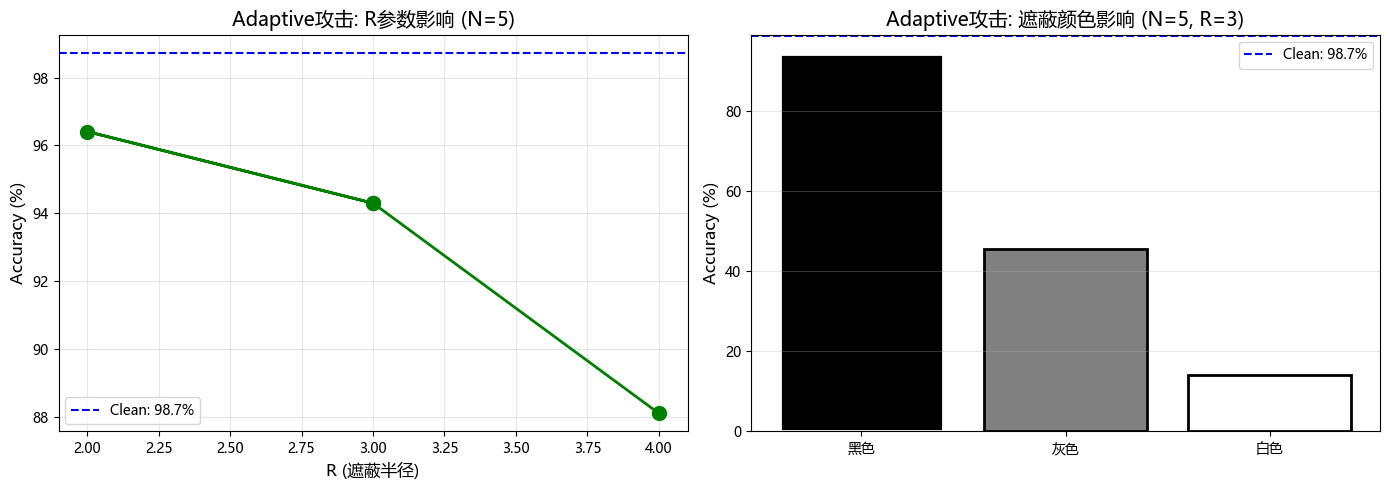

In [17]:
# 绘制R参数和颜色影响
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R参数影响
r_results = [r for r in adaptive_eval_results if r['N'] == 5]
R_vals = [r['R'] for r in r_results]
acc_r = [r['accuracy'] for r in r_results]

axes[0].plot(R_vals, acc_r, 'go-', markersize=10, linewidth=2)
axes[0].axhline(y=clean_acc, color='b', linestyle='--', label=f'Clean: {clean_acc:.1f}%')
axes[0].set_xlabel('R (遮蔽半径)', fontsize=12)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_title('Adaptive攻击: R参数影响 (N=5)', fontsize=14)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# 遮蔽颜色影响
color_accs = [r['accuracy'] for r in color_eval_results]
bar_colors = ['black', 'gray', 'white']
edges = ['white', 'black', 'black']

bars = axes[1].bar(range(len(color_names)), color_accs, color=bar_colors, edgecolor=edges, linewidth=2)
axes[1].set_xticks(range(len(color_names)))
axes[1].set_xticklabels(color_names)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Adaptive攻击: 遮蔽颜色影响 (N=5, R=3)', fontsize=14)
axes[1].axhline(y=clean_acc, color='blue', linestyle='--', label=f'Clean: {clean_acc:.1f}%')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('./results_figures/adaptive_saliency_at_r_color.png', dpi=150, bbox_inches='tight')
plt.show()

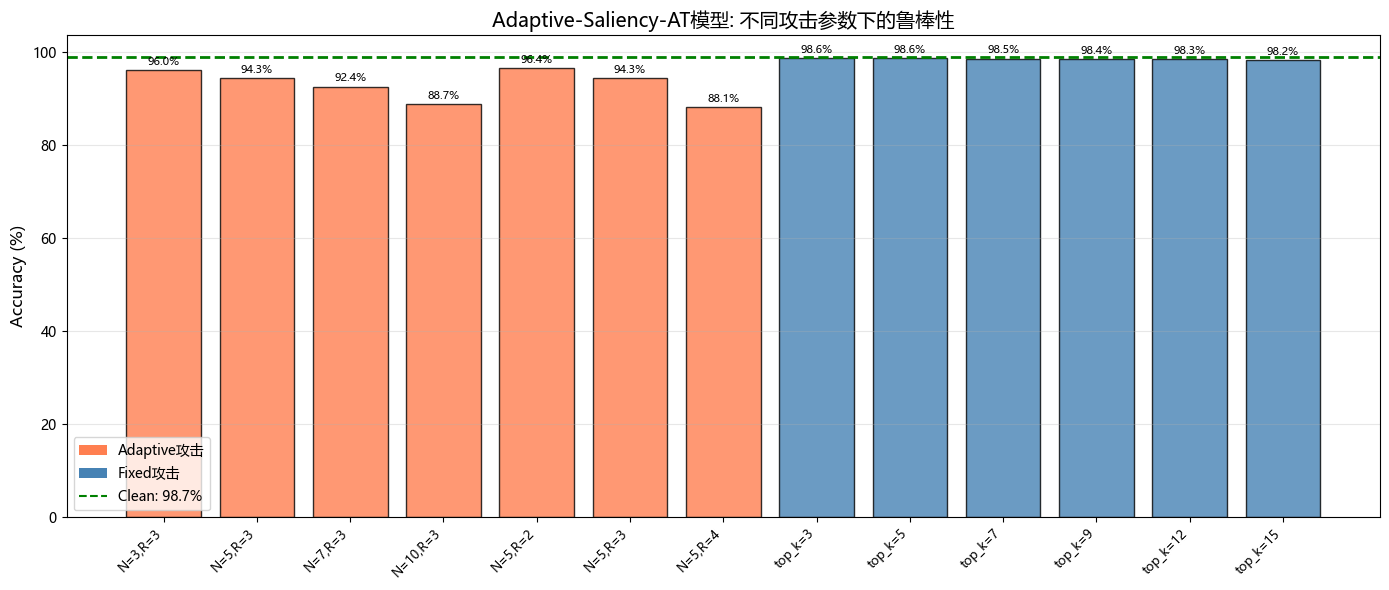

In [18]:
# 综合柱状图展示
fig, ax = plt.subplots(figsize=(14, 6))

# 准备数据
x_pos = np.arange(len(adaptive_eval_results) + len(fixed_eval_results))
acc_all = [r['accuracy'] for r in adaptive_eval_results] + [r['accuracy'] for r in fixed_eval_results]
labels = [r['param'] for r in adaptive_eval_results] + [r['param'] for r in fixed_eval_results]
colors_bar = ['coral'] * len(adaptive_eval_results) + ['steelblue'] * len(fixed_eval_results)

bars = ax.bar(x_pos, acc_all, color=colors_bar, alpha=0.8, edgecolor='black')
ax.axhline(y=clean_acc, color='green', linestyle='--', linewidth=2, label=f'Clean: {clean_acc:.1f}%')

ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=9, rotation=45, ha='right')
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Adaptive-Saliency-AT模型: 不同攻击参数下的鲁棒性', fontsize=14)

# 添加图例
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='coral', label='Adaptive攻击'),
                   Patch(facecolor='steelblue', label='Fixed攻击'),
                   plt.Line2D([0], [0], color='green', linestyle='--', label=f'Clean: {clean_acc:.1f}%')]
ax.legend(handles=legend_elements, fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# 添加数值标签
for bar, val in zip(bars, acc_all):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('./results_figures/adaptive_saliency_at_robustness_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## 15.6 攻击效果可视化（含预测结果）

In [19]:
# 加载标准模型
std_state = torch.load('./save_model/50epoch/mnist_lenet5.pth', map_location=device, weights_only=False)
std_model = LeNet5().to(device)
std_model.load_state_dict(std_state['net'])
std_model.eval()

# 对比评测
comparison_results = []

for model_name, model in [('Standard', std_model), ('Adaptive-Saliency-AT', cnn)]:
    model.eval()
    
    # 干净样本
    clean, _ = test_fn(model, imgs, lbls, bs=250, mode='clean')
    
    # Adaptive攻击 (N=5, R=3)
    attack_adaptive = AdaptiveSaliencyOcclusionAttack(model, N=5, R=3, c=0.0)
    adaptive_acc, _ = test_fn(nn.Sequential(attack_adaptive, model), imgs, lbls, bs=250, mode='attack')
    
    # Adaptive攻击 (N=10, R=3)
    attack_adaptive_10 = AdaptiveSaliencyOcclusionAttack(model, N=10, R=3, c=0.0)
    adaptive_acc_10, _ = test_fn(nn.Sequential(attack_adaptive_10, model), imgs, lbls, bs=250, mode='attack')
    
    # Fixed攻击 (对比)
    attack_fixed = SaliencyOcclusionAttack(model, top_k=9, kernel_size=3, occlu_color=0.0)
    fixed_acc, _ = test_fn(nn.Sequential(attack_fixed, model), imgs, lbls, bs=250, mode='attack')
    
    comparison_results.append({
        'Model': model_name,
        'Clean': round(clean, 2),
        'Adaptive(N=5,R=3)': round(adaptive_acc, 2),
        'Adaptive(N=10,R=3)': round(adaptive_acc_10, 2),
        'Fixed(k=9)': round(fixed_acc, 2)
    })

df_compare = pd.DataFrame(comparison_results)
print('\n========== 标准模型 vs Adaptive-Saliency-AT 对比 ==========')
print(df_compare.to_string(index=False))

NameError: name 'pd' is not defined

# 绘制对比图
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(4)
width = 0.35

std_vals = [comparison_results[0]['Clean'], 
            comparison_results[0]['Adaptive(N=5,R=3)'],
            comparison_results[0]['Adaptive(N=10,R=3)'],
            comparison_results[0]['Fixed(k=9)']]
at_vals = [comparison_results[1]['Clean'], 
           comparison_results[1]['Adaptive(N=5,R=3)'],
           comparison_results[1]['Adaptive(N=10,R=3)'],
           comparison_results[1]['Fixed(k=9)']]

bars1 = ax.bar(x - width/2, std_vals, width, label='Standard', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, at_vals, width, label='Adaptive-Saliency-AT', color='coral', alpha=0.8)

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('标准模型 vs Adaptive-Saliency-AT 鲁棒性对比', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(['Clean', 'Adaptive\n(N=5,R=3)', 'Adaptive\n(N=10,R=3)', 'Fixed\n(k=9)'])
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# 添加数值标签
for bar, val in zip(bars1, std_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', ha='center', fontsize=9)
for bar, val in zip(bars2, at_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('./results_figures/adaptive_saliency_at_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# 保存所有评测结果
df_all = pd.DataFrame(all_results)
df_all.to_csv('./results_figures/adaptive_saliency_at_evaluation_results.csv', index=False)

df_compare.to_csv('./results_figures/adaptive_saliency_at_comparison.csv', index=False)

print('评测结果已保存至:')
print('  - ./results_figures/adaptive_saliency_at_evaluation_results.csv')
print('  - ./results_figures/adaptive_saliency_at_comparison.csv')

## 15.9 总结

### 本实验完成的内容
1. 实现了基于Saliency（简单梯度）的**自适应遮蔽攻击**
2. 训练了自适应Saliency遮蔽攻击对抗性训练模型（50 epochs）
3. 对不同攻击参数进行了评测：
   - Adaptive攻击: 不同N (3, 5, 7, 10) 和 R (2, 3, 4)
   - Fixed攻击: 不同top_k (3, 5, 7, 9, 12, 15) 作为对比
   - 不同kernel_size和遮蔽颜色
4. 可视化了攻击效果（含真实值和预测）
5. 与标准模型进行了对比分析

### 自适应遮蔽攻击的优势
- 使用最小遮蔽量达成攻击
- 保留数字的语义可辨识性
- 攻击更精准，评估更公平

## 15.9 总结

### 本实验完成的内容
1. 实现了基于Saliency（简单梯度）的遮蔽攻击
2. 训练了Saliency遮蔽攻击对抗性训练模型（50 epochs）
3. 对不同攻击参数进行了评测：
   - Fixed攻击: 不同top_k (3, 5, 7, 9, 12, 15)
   - Adaptive攻击: 不同N (3, 5, 7, 10)
   - 不同kernel_size (3, 5, 7)
   - 不同遮蔽颜色（黑、灰、白）
4. 可视化了攻击效果（含真实值和预测）
5. 与标准模型进行了对比分析